In [1]:
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import ROOT

In [2]:
file = 'root://xrootd-cms.infn.it///store/mc/RunIII2024Summer24NanoAODv15/WGtoLNuG-1Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8/NANOAODSIM/150X_mcRun3_2024_realistic_v2-v2/2520000/25ac13b5-27df-4417-9166-c8f92687caea.root'
factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events = factory.events()

In [18]:
len(events)

59377

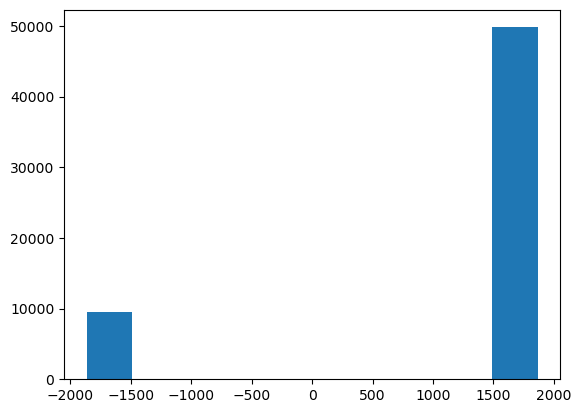

In [33]:
plt.hist(events.genWeight*1);

In [34]:
np.unique(events.genWeight)

<Array [-1.87e+03, 1.87e+03] type='2 * float32'>

In [5]:
events.Photon.pt*1

<Array [[], [13.9, ...], ..., [20.7, 15.5]] type='59377 * var * float32[par...'>

In [6]:
events.Jet.pt*1

<Array [[33.9], [39.5, ...], ..., [56.5, 20.9]] type='59377 * var * float32...'>

In [7]:
gen = events.GenPart

In [8]:
gen_photons = gen[(gen.pdgId == 22) & (gen.status == 1)]

In [10]:
gen_photons.pt*1

<Array [[18.7, 1.55, 1.93], [14], ..., [...]] type='59377 * var * float32[p...'>

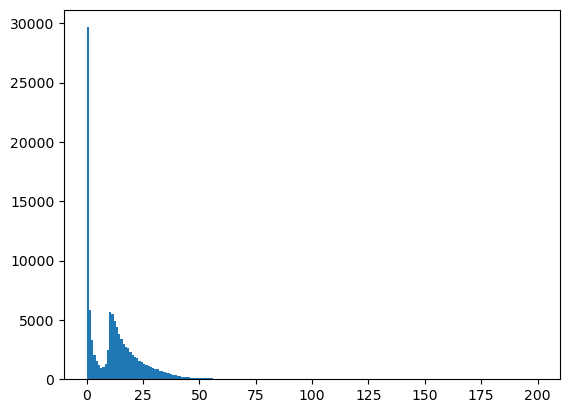

In [12]:
plt.hist(ak.flatten(gen_photons.pt), bins = 200, range = (0, 200));

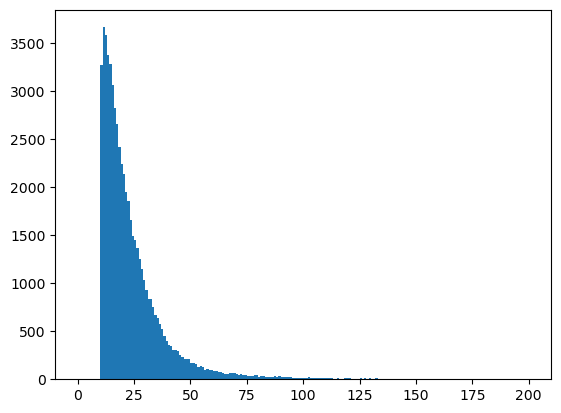

In [13]:
plt.hist(ak.flatten(events.Photon.pt), bins = 200, range = (0, 200));

In [19]:
Photons = events.Photon

In [26]:
Photons[(ak.num(Photons[Photons.pt>15].pt)>=2)].pt

<Array [[40.5, 21], [...], ..., [20.7, 15.5]] type='6899 * var * float32[pa...'>

In [37]:
Electrons = events.Electron
Muons = events.Muon

In [30]:
Electrons[ak.num(Electrons[Electrons.pt>27].pt)>=1].pt*1

<Array [[36.4], [30.7], ..., [33.2, 19.8]] type='6539 * var * float32[param...'>

In [39]:
Muons[ak.num(Muons[Muons.pt>24].pt)>=1].pt*1

<Array [[25.8, 5.12, 3.84], ..., [39.5]] type='6292 * var * float32[paramet...'>

In [21]:
Photons[(ak.num(Photons.pt)>=2) & (Photons.pt>15)].pt

<Array [[], [], ..., [32.2, ...], [20.7, 15.5]] type='59377 * var * float32...'>

In [14]:
Jets = events.Jet
bJets = Jets[Jets.btagUParTAK4B > 0.1272]

In [17]:
bJets[ak.num(bJets.pt)>=1].pt

<Array [[30.3], [21.1], ..., [26], [30.2]] type='8614 * var * float32[param...'>